Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Data preparation

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import time 

In [ ]:
df = pd.read_csv("car_data.csv")
print(df.head)

<bound method NDFrame.head of              DateCrawled  Price  VehicleType  RegistrationYear Gearbox  Power  \
0       24/03/2016 11:52    480          NaN              1993  manual      0   
1       24/03/2016 10:58  18300        coupe              2011  manual    190   
2       14/03/2016 12:52   9800          suv              2004    auto    163   
3       17/03/2016 16:54   1500        small              2001  manual     75   
4       31/03/2016 17:25   3600        small              2008  manual     69   
...                  ...    ...          ...               ...     ...    ...   
354364  21/03/2016 09:50      0          NaN              2005  manual      0   
354365  14/03/2016 17:48   2200          NaN              2005     NaN      0   
354366  05/03/2016 19:56   1199  convertible              2000    auto    101   
354367  19/03/2016 18:57   9200          bus              1996  manual    102   
354368  20/03/2016 19:41   3400        wagon              2002  manual    100  

In [ ]:
print(df.isnull().any().any())
print(df.shape)
null_percentage = (df.isnull().sum() / df.shape[0]) * 100
print(null_percentage)


True
(354369, 16)
DateCrawled           0.000000
Price                 0.000000
VehicleType          10.579368
RegistrationYear      0.000000
Gearbox               5.596709
Power                 0.000000
Model                 5.560588
Mileage               0.000000
RegistrationMonth     0.000000
FuelType              9.282697
Brand                 0.000000
NotRepaired          20.079070
DateCreated           0.000000
NumberOfPictures      0.000000
PostalCode            0.000000
LastSeen              0.000000
dtype: float64


In [ ]:
df[['Price','RegistrationYear','Power','Mileage', 'NumberOfPictures']].describe()

,Price,RegistrationYear,Power,Mileage,NumberOfPictures
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.0
mean,4416.656776,2004.234448,110.094337,128211.172535,0.0
std,4514.158514,90.227958,189.850405,37905.341530,0.0
min,0.000000,1000.000000,0.000000,5000.000000,0.0
25%,1050.000000,1999.000000,69.000000,125000.000000,0.0
50%,2700.000000,2003.000000,105.000000,150000.000000,0.0
75%,6400.000000,2008.000000,143.000000,150000.000000,0.0
max,20000.000000,9999.000000,20000.000000,150000.000000,0.0


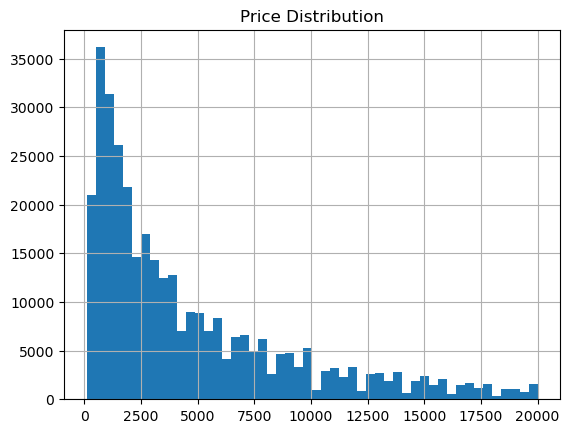

In [ ]:

real_cost = df[(df['Price'] > 100)]

real_cost['Price'].hist(bins=50)
plt.title("Price Distribution")
plt.show()


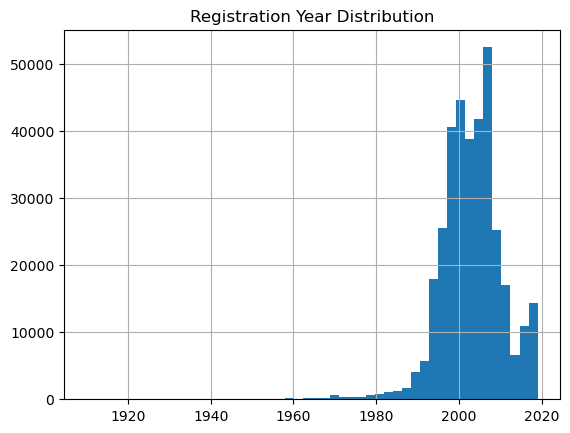

In [ ]:
year = df[(df['RegistrationYear'] > 1900) & (df['RegistrationYear'] < 2026)]

year['RegistrationYear'].hist(bins=50)
plt.title("Registration Year Distribution")
plt.show()

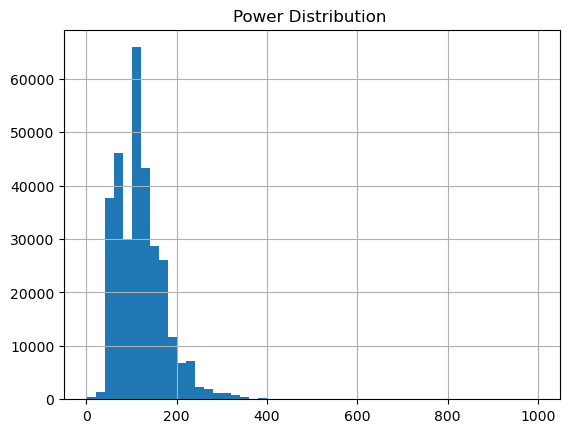

In [ ]:


power_clean = df[(df['Power'] > 0) & (df['Power'] < 1000)]


power_clean['Power'].hist(bins=50)
plt.title("Power Distribution ")
plt.show()

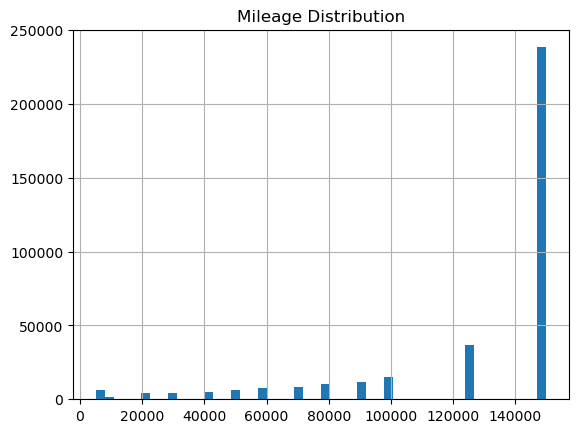

In [ ]:
df['Mileage'].hist(bins=50)
plt.title("Mileage Distribution")
plt.show()


In [ ]:
print("Price = 0 rows:", (df['Price'] <= 0).sum())
print("Invalid RegistrationYear (<1900):", (df['RegistrationYear'] < 1900).sum())
print("Future RegistrationYear (>2026):", (df['RegistrationYear'] > 2024).sum())
print("Power = 0 rows:", (df['Power'] <= 0).sum())

df = df[df['Price'] > 0]
df = df[df['RegistrationYear'] >= 1900]
df = df[df['RegistrationYear'] <= 2026]
df = df[df['Power'] > 0]
df = df[df['Power'] < 1000]

# finish filtering and decide where to clamp it

Price = 0 rows: 10772
Invalid RegistrationYear (<1900): 66
Future RegistrationYear (>2026): 105
Power = 0 rows: 40225


In [ ]:
df = df.drop(['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures'], axis=1)
print(df.head)

<bound method NDFrame.head of         Price  VehicleType  RegistrationYear Gearbox  Power        Model  \
1       18300        coupe              2011  manual    190          NaN   
2        9800          suv              2004    auto    163        grand   
3        1500        small              2001  manual     75         golf   
4        3600        small              2008  manual     69        fabia   
5         650        sedan              1995  manual    102          3er   
...       ...          ...               ...     ...    ...          ...   
354361   5250          NaN              2016    auto    150          159   
354362   3200        sedan              2004  manual    225         leon   
354366   1199  convertible              2000    auto    101       fortwo   
354367   9200          bus              1996  manual    102  transporter   
354368   3400        wagon              2002  manual    100         golf   

        Mileage  RegistrationMonth  FuelType       Brand 

In [ ]:
df['VehicleType'].fillna('unknown', inplace=True)
df['Gearbox'].fillna('unknown', inplace=True)
df['Model'].fillna('unknown', inplace=True)
df['FuelType'].fillna('unknown', inplace=True)
df['NotRepaired'].fillna('unknown', inplace=True)
print(df.head)

<bound method NDFrame.head of         Price  VehicleType  RegistrationYear Gearbox  Power        Model  \
1       18300        coupe              2011  manual    190      unknown   
2        9800          suv              2004    auto    163        grand   
3        1500        small              2001  manual     75         golf   
4        3600        small              2008  manual     69        fabia   
5         650        sedan              1995  manual    102          3er   
...       ...          ...               ...     ...    ...          ...   
354361   5250      unknown              2016    auto    150          159   
354362   3200        sedan              2004  manual    225         leon   
354366   1199  convertible              2000    auto    101       fortwo   
354367   9200          bus              1996  manual    102  transporter   
354368   3400        wagon              2002  manual    100         golf   

        Mileage  RegistrationMonth  FuelType       Brand 

C:\Users\mmend\AppData\Local\Temp\ipykernel_7200\802584180.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['VehicleType'].fillna('unknown', inplace=True)
C:\Users\mmend\AppData\Local\Temp\ipykernel_7200\802584180.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [ ]:
duplicate_percentage = (df.duplicated().sum() / df.shape[0]) * 100
print(f"Duplicate rows: {duplicate_percentage:.2f}%")
print(df.shape)
# print(df[df.duplicated()])

Duplicate rows: 6.26%
(306915, 12)


In [ ]:
df = df.drop_duplicates()
print(df.shape)

(287709, 12)


Exploratory analysis revealed several unrealistic values, including vehicles with zero price and registration years which don't make any sense, suggesting possible data entry errors. These records were removed to improve data quality. In addition, columns that did not contribute meaningful information for price prediction or could introduce unnecessary noise were excluded to reduce the risk of overfitting. The resulting dataset provides a cleaner and more reliable basis for model training.

In [ ]:
df_temp, df_test = train_test_split(df, test_size=0.2, random_state=12345)

# Second split: divide remaining into train (60%) and validation (20%)
df_train, df_valid = train_test_split(df_temp, test_size=0.25, random_state=12345)

In [ ]:

print(df['Model'].nunique())
#print(df['Model'].value_counts())
print((df['Model'].value_counts() < 200).sum())

model_counts = df['Model'].value_counts()
common_models = model_counts[model_counts >= 200].index
df['Model'] = df['Model'].apply(lambda x: x if x in common_models else 'other')
print(df['Model'].value_counts())

# rename to other

250
92
Model
other       28351
golf        24424
3er         16642
unknown     12023
polo        10453
            ...  
xc_reihe      212
auris         208
carnival      207
cayenne       206
tucson        202
Name: count, Length: 158, dtype: int64


In [ ]:



categorical_columns = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)





One-Hot Encoding was used for categorical features to make them usable for models that require numeric input. However, some columns, such as Model and Brand, have high cardinality, meaning they contain many unique values. Applying One-Hot Encoding directly to these features can create a large number of additional columns and reduce computational efficiency. To mitigate this issue, rare Model categories appearing fewer than 200 times were grouped into an "other" category before encoding. This reduces the number of generated features while preserving the most common models. In practice, alternative approaches such as frequency encoding or models like CatBoost, which handle categorical features natively, may scale better for high-cardinality variables.

In [ ]:
target = df['Price']
features = df.drop('Price', axis=1)

X_train = df_train.drop('Price', axis=1)  # Features only
Y_train = df_train['Price']               # Target only

X_valid = df_valid.drop('Price', axis=1)  # Features only  
Y_valid = df_valid['Price']               # Target only

X_test = df_test.drop('Price', axis=1)    # Features only
Y_test = df_test['Price']

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)


In [ ]:
print("Price statistics:")
print(f"Mean: €{Y_train.mean():.2f}")
print(f"Min: €{Y_train.min():.2f}")
print(f"Max: €{Y_train.max():.2f}")
print(f"Std: €{Y_train.std():.2f}")


Price statistics:
Mean: €4775.68
Min: €1.00
Max: €20000.00
Std: €4578.07


In [ ]:

start_time = time.time() # start instant

model = LinearRegression()


model.fit(X_train, Y_train)
end_time = time.time()
 # calculate elapsed time
 # start instant




end_time = time.time()
lr_train_time = end_time - start_time
print(f"Elapsed time: {lr_train_time:.4f} seconds")



Elapsed time: 0.2524 seconds


In [ ]:
start_time = time.time()

predicted_valid = model.predict(X_valid)

# Calculate metrics and store them in variables
lr_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
lr_mae = mean_absolute_error(Y_valid, predicted_valid)
lr_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
lr_inference_time = end_time - start_time


print('Linear Regression')
print('Linear Regression Results:')
print(f'RMSE: €{lr_rmse:.2f}')
print(f'MAE: €{lr_mae:.2f}')
print(f'R² Score: {lr_r2:.2f}%')
print(f"Inference time: {lr_inference_time:.4f} seconds")

Linear Regression
Linear Regression Results:
RMSE: €2849.20
MAE: €2023.20
R² Score: 61.03%
Inference time: 0.0151 seconds


Compared to a baseline that predicts the mean price, Linear Regression provides a substantial improvement, achieving an R² of 0.61%. However, the error is still relatively large, indicating that the linear model may not fully capture the complexity of the data. Next, more flexible models will be tested to see if prediction accuracy can be improved

In [ ]:

start_time = time.time()

random_forest = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=12345
)

random_forest.fit(X_train, Y_train)

end_time = time.time()
rf_train_time = end_time - start_time

print(f"Random Forest training time: {rf_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

predicted_valid = random_forest.predict(X_valid)

# Store metrics in variables
rf_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
rf_mae = mean_absolute_error(Y_valid, predicted_valid)
rf_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
rf_inference_time = end_time - start_time


print("Random Forest Results:")
print(f"RMSE: €{rf_rmse:.2f}")
print(f"MAE: €{rf_mae:.2f}")
print(f"R² Score: {rf_r2:.2f}%")
print(f"Inference time: {rf_inference_time:.4f} seconds")

Random Forest training time: 466.2558 seconds
Random Forest Results:
RMSE: €1700.67
MAE: €1056.65
R² Score: 86.11%
Inference time: 0.3617 seconds


In [ ]:


# TRAINING TIME
# -----------------------------
start_time = time.time()

decision_tree = DecisionTreeRegressor(random_state=12345)
decision_tree.fit(X_train, Y_train)

end_time = time.time()
dt_train_time = end_time - start_time

print(f"Decision Tree training time: {dt_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

predicted_valid = decision_tree.predict(X_valid)

# Store metrics in variables
dt_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
dt_mae = mean_absolute_error(Y_valid, predicted_valid)
dt_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
dt_inference_time = end_time - start_time


print("Decision Tree Results:")
print(f"RMSE: €{dt_rmse:.2f}")
print(f"MAE: €{dt_mae:.2f}")
print(f"R² Score: {dt_r2:.2f}%")
print(f"Inference time: {dt_inference_time:.4f} seconds")



Decision Tree training time: 177.3418 seconds
Decision Tree Results:
RMSE: €2199.11
MAE: €1310.36
R² Score: 76.78%
Inference time: 0.0966 seconds


In [ ]:

# TRAINING TIME
# -----------------------------
start_time = time.time()

LGBMR = LGBMRegressor(
    learning_rate=0.1,
    num_leaves=255,
    n_estimators=500
)

LGBMR.fit(X_train, Y_train)

end_time = time.time()
lgbm_train_time = end_time - start_time

print(f"LightGBM training time: {lgbm_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

predicted_valid = LGBMR.predict(X_valid)

# Store metrics in variables
lgbm_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
lgbm_mae = mean_absolute_error(Y_valid, predicted_valid)
lgbm_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
lgbm_inference_time = end_time - start_time


print("LightGBM Results:")
print(f"RMSE: €{lgbm_rmse:.2f}")
print(f"MAE: €{lgbm_mae:.2f}")
print(f"R² Score: {lgbm_r2:.2f}%")
print(f"Inference time: {lgbm_inference_time:.4f} seconds")



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1194
[LightGBM] [Info] Number of data points in the train set: 172625, number of used features: 298
[LightGBM] [Info] Start training from score 4775.681327
LightGBM training time: 23.0465 seconds


C:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM Results:
RMSE: €1555.74
MAE: €966.94
R² Score: 88.38%
Inference time: 1.0182 seconds


In [ ]:

# TRAINING TIME
# -----------------------------
start_time = time.time()

cat_model = CatBoostRegressor(
    learning_rate=0.1,
    iterations=500,
    depth=8,
    verbose=0
)

cat_model.fit(X_train, Y_train)

end_time = time.time()
cat_train_time = end_time - start_time

print(f"CatBoost training time: {cat_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

predicted_valid = cat_model.predict(X_valid)

# Store metrics in variables
cat_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
cat_mae = mean_absolute_error(Y_valid, predicted_valid)
cat_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
cat_inference_time = end_time - start_time


print("CatBoost Results:")
print(f"RMSE: €{cat_rmse:.2f}")
print(f"MAE: €{cat_mae:.2f}")
print(f"R² Score: {cat_r2:.2f}%")
print(f"Inference time: {cat_inference_time:.4f} seconds")

CatBoost training time: 12.8302 seconds
CatBoost Results:
RMSE: €1607.10
MAE: €1019.61
R² Score: 87.60%
Inference time: 0.1541 seconds


In [ ]:
# TRAINING TIME
# -----------------------------
start_time = time.time()

xgb_model = XGBRegressor(
    learning_rate=0.1,
    n_estimators=500,
    max_depth=8,
    random_state=12345
)

xgb_model.fit(X_train, Y_train)

end_time = time.time()
xgb_train_time = end_time - start_time

print(f"XGBoost training time: {xgb_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

predicted_valid = xgb_model.predict(X_valid)

# Store metrics in variables
xgb_rmse = np.sqrt(mean_squared_error(Y_valid, predicted_valid))
xgb_mae = mean_absolute_error(Y_valid, predicted_valid)
xgb_r2 = r2_score(Y_valid, predicted_valid) * 100

end_time = time.time()
xgb_inference_time = end_time - start_time


print("XGBoost Results:")
print(f"RMSE: €{xgb_rmse:.2f}")
print(f"MAE: €{xgb_mae:.2f}")
print(f"R² Score: {xgb_r2:.2f}%")
print(f"Inference time: {xgb_inference_time:.4f} seconds")


XGBoost training time: 4.8571 seconds
XGBoost Results:
RMSE: €1592.80
MAE: €997.91
R² Score: 87.82%
Inference time: 0.4016 seconds


In [ ]:

results_df = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree','Random Forest','LightGBM','CatBoost','XGBoost'],
    'RMSE (€)': [lr_rmse, dt_rmse, rf_rmse, lgbm_rmse, cat_rmse, xgb_rmse],
    'MAE (€)': [lr_mae, dt_mae, rf_mae, lgbm_mae, cat_mae, xgb_mae],
    'R² Score (%)': [lr_r2, dt_r2, rf_r2, lgbm_r2, cat_r2, xgb_r2],
    'Training Time (s)': [lr_train_time, dt_train_time, rf_train_time, lgbm_train_time, cat_train_time, xgb_train_time],
    'Inference Time (s)': [lr_inference_time, dt_inference_time, rf_inference_time, lgbm_inference_time, cat_inference_time, xgb_inference_time]
})

# Sort by best model (lowest RMSE)
results_df = results_df.sort_values(by='RMSE (€)')

print(results_df)

               Model     RMSE (€)      MAE (€)  R² Score (%)  \
3           LightGBM  1555.735598   966.938977     88.380222   
5            XGBoost  1592.803111   997.914246     87.819910   
4           CatBoost  1607.104807  1019.609488     87.600201   
2      Random Forest  1700.669526  1056.646599     86.114353   
1      Decision Tree  2199.110772  1310.360768     76.782232   
0  Linear Regression  2849.202955  2023.199468     61.026175   

   Training Time (s)  Inference Time (s)  
3          23.046529            1.018218  
5           4.857133            0.401567  
4          12.830164            0.154116  
2         466.255817            0.361670  
1         177.341755            0.096638  
0           0.252351            0.015066  


In [ ]:
models = {
    'Linear Regression': model,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'LightGBM': LGBMR,
    'CatBoost': cat_model,
    'XGBoost': xgb_model
}
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best model selected: {best_model_name}")

Best model selected: LightGBM


The model comparison shows that gradient boosting models achieved the best predictive performance. LightGBM produced the lowest RMSE (€1555.74) and the highest R² score (88.38%), making it the most accurate model among those tested. XGBoost and CatBoost also performed very well, with only slightly higher prediction errors. Random Forest delivered solid results but did not match the performance of the boosting models. The Decision Tree model performed moderately well but showed higher error and lower explanatory power compared to the ensemble models, suggesting that a single tree is not sufficient to capture the complexity of the data. Linear Regression performed the worst overall, indicating that the relationship between vehicle features and price is likely nonlinear and better modeled by tree-based ensemble methods.

To confirm that the selected model generalizes well and does not overfit the validation data, the best-performing model is evaluated on the test dataset.

In [ ]:



start_test = time.time()

test_predictions = best_model.predict(X_test)

test_time = time.time() - start_test

test_rmse = np.sqrt(mean_squared_error(Y_test, test_predictions))
test_mae = mean_absolute_error(Y_test, test_predictions)
test_r2 = r2_score(Y_test, test_predictions) * 100

print("Final Model Test Results:")
print(f"Model: {best_model_name}")
print(f"RMSE: €{test_rmse:.2f}")
print(f"MAE: €{test_mae:.2f}")
print(f"R² Score: {test_r2:.2f}%")
print(f"Prediction Time on Test Set: {test_time:.4f} seconds")

C:\Users\mmend\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Final Model Test Results:
Model: LightGBM
RMSE: €1549.85
MAE: €965.55
R² Score: 88.62%
Prediction Time on Test Set: 1.4543 seconds


The LightGBM model achieved the best performance among all evaluated models and was therefore selected for final testing. On the validation set, the model obtained an RMSE of €1555.74, an MAE of €966.94, and an R² score of 88.38%. When evaluated on the test set, the performance remained very similar, with an RMSE of €1549.85, an MAE of €965.55, and an R² score of 88.62%. The close agreement between validation and test results indicates that the model generalizes well to unseen data and does not appear to suffer from significant overfitting. This consistency suggests that the model captures the underlying patterns in the dataset effectively while maintaining stable predictive performance.

# Checklist

Type 'x' to check. Then press Shift+Enter.

- [x]  Jupyter Notebook is open
- [ ]  Code is error free
- [ ]  The cells with the code have been arranged in order of execution
- [ ]  The data has been downloaded and prepared
- [ ]  The models have been trained
- [ ]  The analysis of speed and quality of the models has been performed